<a href="https://colab.research.google.com/github/Ab-126/Machine_Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

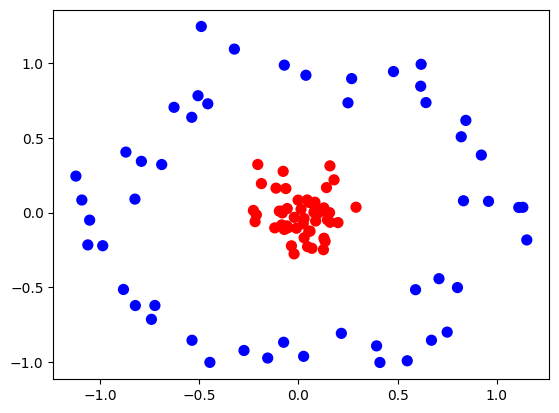

In [4]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5

In [8]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_766/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


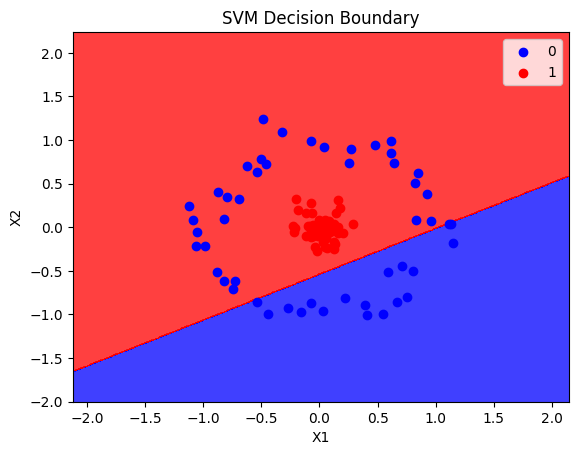

In [10]:
plot_decision_boundary(X, y, classifier)

In [11]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

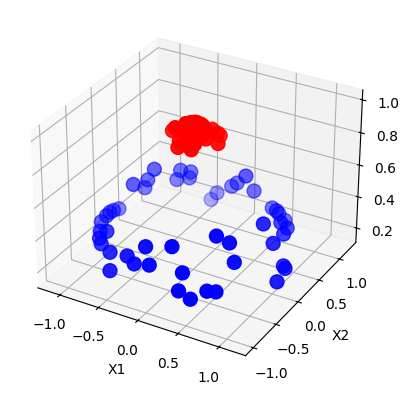

In [12]:
plot_3d_plot(X, y)

In [13]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [14]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_766/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


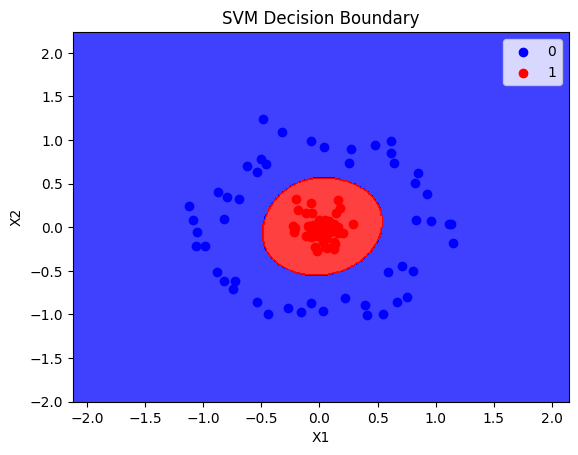

In [15]:
plot_decision_boundary(X, y, rbf_classifier)

In [20]:
poly_classifier = SVC(kernel="poly", degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [21]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_766/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


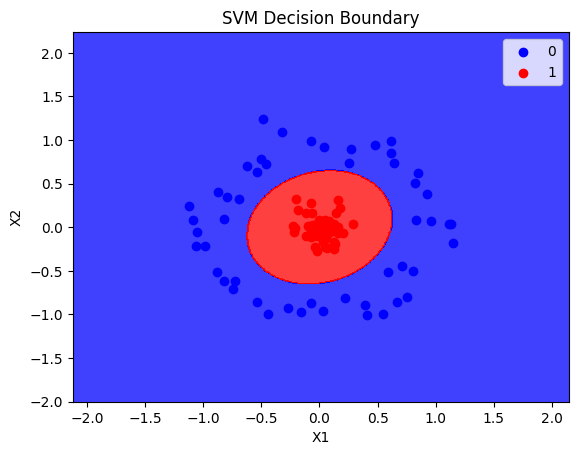

In [22]:
plot_decision_boundary(X, y, poly_classifier)

In [23]:
X

array([[-3.23340196e-01,  1.09421969e+00],
       [ 1.25855471e-01, -2.47563765e-01],
       [ 4.10987315e-01, -1.00204411e+00],
       [-1.19577605e-01, -1.01626630e-01],
       [-4.46852307e-01, -1.00123842e+00],
       [-5.82713432e-02, -8.85411528e-02],
       [ 7.80040101e-02,  2.44019463e-03],
       [-8.82853774e-01, -5.13517430e-01],
       [-2.18946978e-01, -5.98796295e-02],
       [ 7.08920752e-01, -4.41578561e-01],
       [ 8.44486822e-01,  6.17328772e-01],
       [ 7.67011789e-02,  5.40030630e-02],
       [ 2.49805140e-01,  7.34910855e-01],
       [ 1.15195367e+00, -1.82439584e-01],
       [-1.06263324e+00, -2.15621665e-01],
       [-8.14007313e-02, -1.34287188e-03],
       [ 6.43328812e-01,  7.36364882e-01],
       [ 8.02111510e-01, -5.00913374e-01],
       [ 2.90296054e-01,  3.65614037e-02],
       [-8.41843227e-02,  9.11683122e-03],
       [ 1.56860627e-01,  1.80968398e-05],
       [ 2.40994474e-02, -7.41731428e-02],
       [ 8.31824032e-02,  7.00014643e-02],
       [-5.

In [24]:
np.exp(-(X**2)).sum(1)

array([1.20273425, 1.92483768, 1.21096144, 1.97552812, 1.18596408,
       1.98880132, 1.99392789, 1.22687087, 1.94961394, 1.42781625,
       1.17320716, 1.99122212, 1.52219806, 1.23253623, 1.27786674,
       1.99339402, 1.24253388, 1.3036008 , 1.91784555, 1.99285494,
       1.97569499, 1.99393284, 1.98821635, 1.41399611, 1.95475907,
       1.98146441, 1.97665094, 1.99932435, 1.42233585, 1.95572632,
       1.42814516, 1.28289377, 1.12030989, 1.88169325, 1.46600776,
       1.99247863, 1.99858263, 1.05512779, 1.98939794, 1.98612217,
       1.47234519, 1.9827165 , 1.28229594, 1.39962166, 1.39638509,
       1.97081062, 1.27199183, 1.98231331, 1.37797822, 1.94600878,
       1.98916837, 1.09772502, 1.27636649, 1.94014996, 1.99085606,
       1.95073857, 1.49813694, 1.22533557, 1.97146348, 1.2894475 ,
       1.39302723, 0.99837534, 1.20490235, 1.35474604, 1.99062794,
       1.37257849, 1.97027909, 1.99098893, 1.23205472, 1.9976473 ,
       1.31713423, 1.32715084, 1.94937471, 1.95242669, 1.11470

In [25]:
X_new=np.exp(-(X**2))

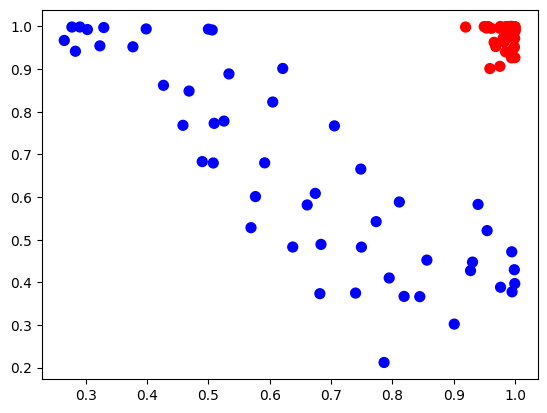

In [26]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')